In [5]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, ConfusionMatrixDisplay
)

SAVE_PATH = r"D:\Stress Detection\data"

X    = np.load(os.path.join(SAVE_PATH, 'X_scaled.npy'))
y    = np.load(os.path.join(SAVE_PATH, 'y.npy'))
subs = np.load(os.path.join(SAVE_PATH, 'subjects.npy'))

model_files = {
    'SVM'          : 'svm_model.pkl',
    'Decision Tree': 'decision_tree_model.pkl',
    'Random Forest': 'random_forest_model.pkl',
    'ANN'          : 'ann_model.pkl',
}

models = {}
for name, fname in model_files.items():
    models[name] = joblib.load(os.path.join(SAVE_PATH, fname))
    print(f"  loaded {name}")

  loaded SVM
  loaded Decision Tree
  loaded Random Forest
  loaded ANN


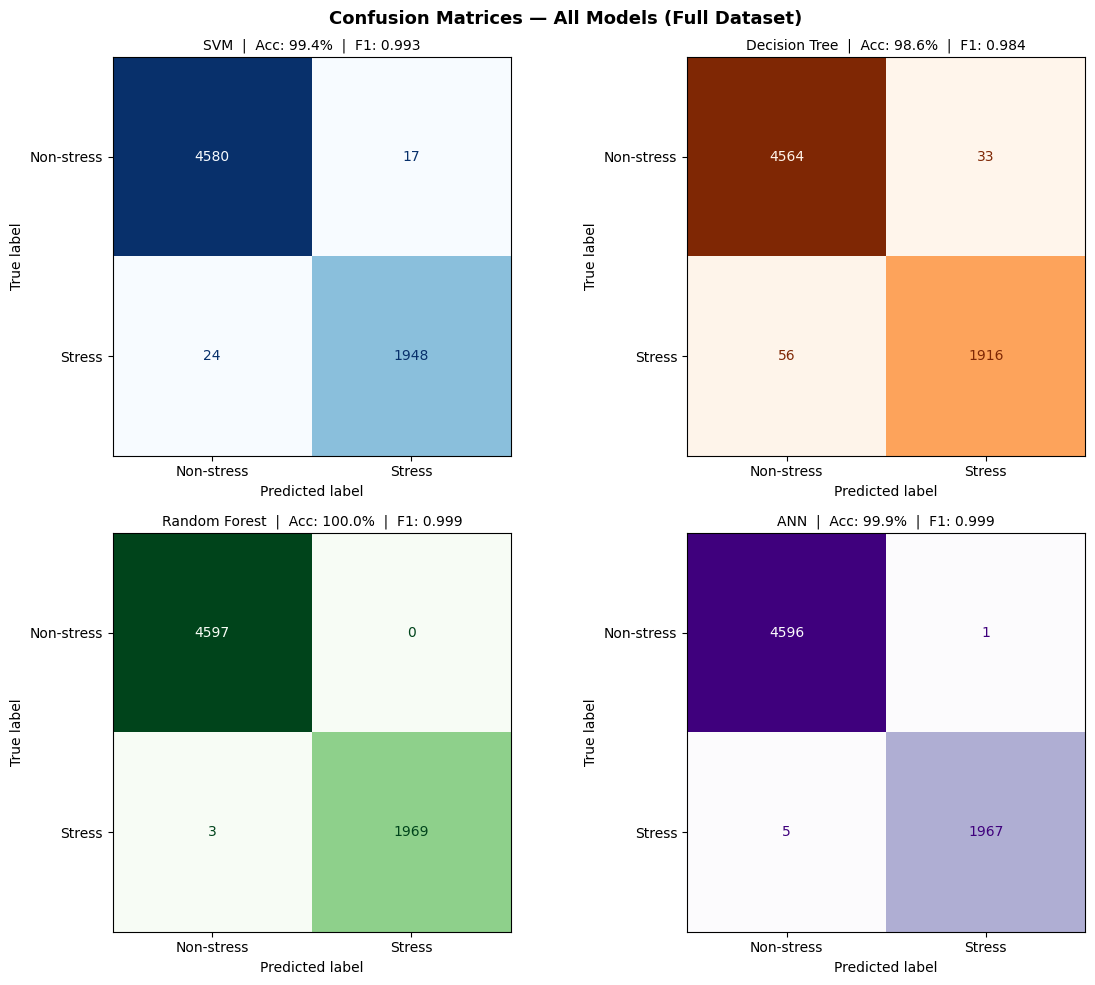

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices — All Models (Full Dataset)',
             fontsize=13, fontweight='bold')

axes_flat = axes.flatten()
colors    = ['Blues', 'Oranges', 'Greens', 'Purples']

for ax, (m_name, model), cmap in zip(axes_flat, models.items(), colors):
    preds = model.predict(X)
    cm    = confusion_matrix(y, preds)
    disp  = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=['Non-stress', 'Stress']
            )
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    acc = accuracy_score(y, preds) * 100
    f1  = f1_score(y, preds, average='macro')
    ax.set_title(f'{m_name}  |  Acc: {acc:.1f}%  |  F1: {f1:.3f}',
                 fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'confusion_matrices.png'),
            dpi=120, bbox_inches='tight')
plt.show()

In [7]:
rows = []
for m_name, model in models.items():
    preds = model.predict(X)
    rows.append({
        'Model'         : m_name,
        'Accuracy (%)'  : round(accuracy_score(y, preds) * 100, 2),
        'Precision'     : round(precision_score(y, preds, average='macro',
                                                zero_division=0), 3),
        'Recall'        : round(recall_score(y, preds, average='macro',
                                             zero_division=0), 3),
        'F1 (macro)'    : round(f1_score(y, preds, average='macro',
                                         zero_division=0), 3),
    })

metrics_df = pd.DataFrame(rows)
print("="*62)
print("FULL EVALUATION METRICS")
print("="*62)
print(metrics_df.to_string(index=False))
print("="*62)

# Save metrics
metrics_df.to_csv(os.path.join(SAVE_PATH, 'model_metrics.csv'), index=False)
print("\nSaved model_metrics.csv")

FULL EVALUATION METRICS
        Model  Accuracy (%)  Precision  Recall  F1 (macro)
          SVM         99.38      0.993   0.992       0.993
Decision Tree         98.65      0.985   0.982       0.984
Random Forest         99.95      1.000   0.999       0.999
          ANN         99.91      0.999   0.999       0.999

Saved model_metrics.csv


In [8]:
# ── Custom Stress Index formula ──────────────────────────────────────────────
# Uses Random Forest predict_proba → stress probability
# Maps to 0–100 with physiological weighting:
#   - base score from RF stress probability
#   - boosted if EDA is elevated above subject's baseline
#   - capped at 100

def compute_stress_index(model, X_window, eda_value,
                         eda_baseline_mean, eda_baseline_std):
    """
    Parameters:
        model            : trained Random Forest (has predict_proba)
        X_window         : scaled feature vector, shape (1, n_features)
        eda_value        : mean EDA of this window (raw, unscaled)
        eda_baseline_mean: subject's baseline EDA mean
        eda_baseline_std : subject's baseline EDA std

    Returns:
        stress_index (float): 0–100
        category (str)      : Low / Moderate / High
    """
    # Base score from model probability
    stress_prob = model.predict_proba(X_window)[0][1]  # P(stress)
    base_score  = stress_prob * 100

    # Physiological boost: EDA z-score above baseline
    eda_z = (eda_value - eda_baseline_mean) / (eda_baseline_std + 1e-8)
    eda_boost = np.clip(eda_z * 5, -10, 15)   # max ±15 point adjustment

    stress_index = np.clip(base_score + eda_boost, 0, 100)

    if stress_index <= 35:
        category = "Low"
    elif stress_index <= 65:
        category = "Moderate"
    else:
        category = "High"

    return round(float(stress_index), 1), category


# ── Demo: compute stress index for each subject ──────────────────────────────
rf_model     = models['Random Forest']
scaler       = joblib.load(os.path.join(SAVE_PATH, 'scaler.pkl'))
feature_names = joblib.load(os.path.join(SAVE_PATH, 'feature_names.pkl'))

print("="*55)
print("SUBJECT-WISE STRESS INDEX (Random Forest)")
print("="*55)

subject_scores = []

for sid, data in {s: d for s, d in
                  zip(np.unique(subs),
                      [None]*len(np.unique(subs)))}.items():
    # reload subject for EDA baseline
    pkl_path = os.path.join(SAVE_PATH.replace('StressDetection','StressDetection'),
                            'WESAD', sid, f"{sid}.pkl")
    # ── safer: just use subject mask from X ─────────────────────────────────
    mask     = subs == sid
    X_sub    = X[mask]
    y_sub    = y[mask]

    if len(X_sub) == 0:
        continue

    preds_sub  = rf_model.predict(X_sub)
    stress_pct = np.mean(preds_sub == 1) * 100

    # Simplified stress index (without raw EDA — already scaled)
    # Use mean predicted probability across all windows
    proba_sub  = rf_model.predict_proba(X_sub)[:, 1]
    mean_score = np.clip(np.mean(proba_sub) * 100, 0, 100)

    if mean_score <= 35:   category = "Low"
    elif mean_score <= 65: category = "Moderate"
    else:                  category = "High"

    subject_scores.append({
        'Subject'     : sid,
        'Stress Index': round(mean_score, 1),
        'Category'    : category,
        'Stress %'    : round(stress_pct, 1)
    })
    print(f"  {sid}: index={mean_score:.1f}  →  {category}")

scores_df = pd.DataFrame(subject_scores)
print("="*55)

SUBJECT-WISE STRESS INDEX (Random Forest)
  S10: index=31.8  →  Low
  S11: index=31.3  →  Low
  S13: index=29.0  →  Low
  S14: index=31.2  →  Low
  S15: index=29.3  →  Low
  S16: index=30.7  →  Low
  S17: index=31.8  →  Low
  S2: index=28.3  →  Low
  S3: index=30.0  →  Low
  S4: index=27.9  →  Low
  S5: index=29.6  →  Low
  S6: index=29.4  →  Low
  S7: index=30.6  →  Low
  S8: index=30.0  →  Low
  S9: index=28.7  →  Low


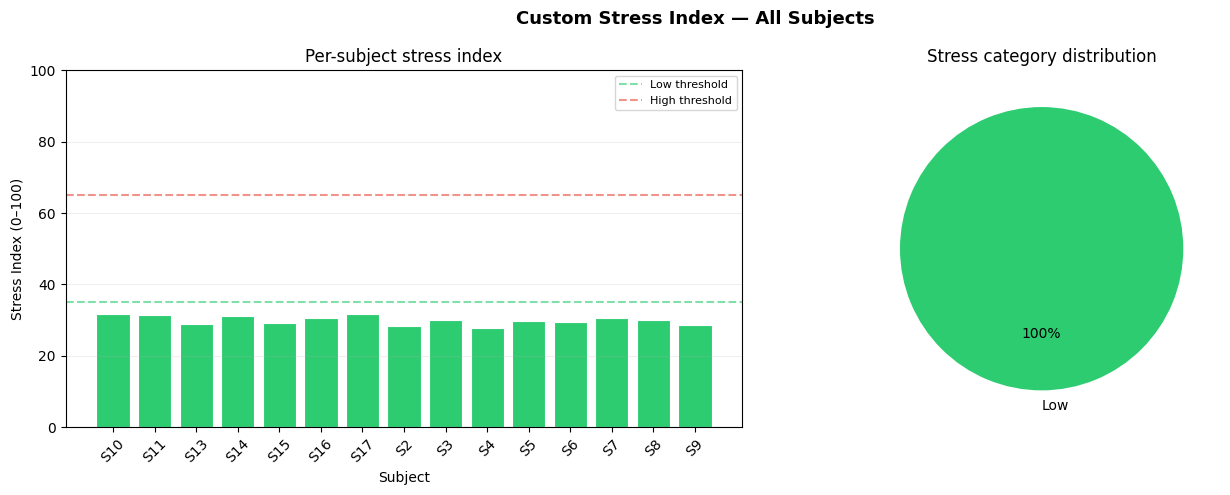

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Custom Stress Index — All Subjects', fontsize=13, fontweight='bold')

cat_colors = {'Low':'#2ecc71', 'Moderate':'#f39c12', 'High':'#e74c3c'}
bar_colors = [cat_colors[c] for c in scores_df['Category']]

# Bar chart
axes[0].bar(scores_df['Subject'], scores_df['Stress Index'],
            color=bar_colors, edgecolor='white', linewidth=0.8)
axes[0].axhline(35, color='#2ecc71', linestyle='--', alpha=0.6, label='Low threshold')
axes[0].axhline(65, color='#e74c3c', linestyle='--', alpha=0.6, label='High threshold')
axes[0].set_ylabel('Stress Index (0–100)')
axes[0].set_xlabel('Subject')
axes[0].set_title('Per-subject stress index')
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.2)

# Category distribution
cat_counts = scores_df['Category'].value_counts()
axes[1].pie(cat_counts.values,
            labels=cat_counts.index,
            colors=[cat_colors[c] for c in cat_counts.index],
            autopct='%1.0f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Stress category distribution')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'stress_index.png'),
            dpi=120, bbox_inches='tight')
plt.show()

In [10]:
# ── Save everything Streamlit app will need ──────────────────────────────────

# Best model for deployment = Random Forest
joblib.dump(rf_model, os.path.join(SAVE_PATH, 'best_model.pkl'))
print("Saved best_model.pkl  (Random Forest)")

# Metrics for display in app
metrics_df.to_csv(os.path.join(SAVE_PATH, 'model_metrics.csv'), index=False)
print("Saved model_metrics.csv")

# Stress index thresholds (used in app)
import json
thresholds = {'low': 35, 'moderate': 65,
              'categories': ['Low','Moderate','High'],
              'colors':     ['#2ecc71','#f39c12','#e74c3c']}
with open(os.path.join(SAVE_PATH, 'thresholds.json'), 'w') as f:
    json.dump(thresholds, f)
print("Saved thresholds.json")

print()
print("Files ready for Streamlit app:")
print(f"  {SAVE_PATH}/best_model.pkl")
print(f"  {SAVE_PATH}/scaler.pkl")
print(f"  {SAVE_PATH}/feature_names.pkl")
print(f"  {SAVE_PATH}/model_metrics.csv")
print(f"  {SAVE_PATH}/thresholds.json")
print()
print("NB04 complete ✓  →  Phase 1 done. Proceed to Streamlit app.")

Saved best_model.pkl  (Random Forest)
Saved model_metrics.csv
Saved thresholds.json

Files ready for Streamlit app:
  D:\Stress Detection\data/best_model.pkl
  D:\Stress Detection\data/scaler.pkl
  D:\Stress Detection\data/feature_names.pkl
  D:\Stress Detection\data/model_metrics.csv
  D:\Stress Detection\data/thresholds.json

NB04 complete ✓  →  Phase 1 done. Proceed to Streamlit app.
